# Plotting

This file is responsible for plotting the results of the models.
The data should be shown in an easy-to-understand manner and all plots should have some guidance
on interpretation and background.

Follow the following guidance:
- Make all assumptions clear.
- Do not hardcode any variables. All must be visible in the sources tab.
- No data computations may be done and only data from ../results may be accessed.

In [7]:
from pathlib import Path
import sys

# Set matlplotlib to inline mode
%matplotlib inline
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

In [9]:
# Import the configurations
from configs import PLOTTING_CONFIG
from src.plotting import PLOTTER, import_plotting_data, tree_plot_portfolios

plotter: PLOTTER = PLOTTER(PLOTTING_CONFIG)

# Import the Data

In [10]:
# Import files and set index

monthly_factor_loadings, monthly_predicted_returns, factor_loadings_overtime = (
    import_plotting_data()
)

/Users/matswalker/Downloads/FinalThesis/src/plotting/utils.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  factor_loadings_overtime: pd.DataFrame = pd.read_csv(


In [20]:
print(monthly_factor_loadings.T.describe())

            Beta                                                         \
           Alpha        CMA        HML     Mkt-RF        RMW        SMB   
count  99.000000  99.000000  99.000000  99.000000  99.000000  99.000000   
mean   -0.003572   0.054910   0.083034   1.049041   0.061407   0.407545   
std     0.006324   0.319906   0.317878   0.251172   0.325858   0.453452   
min    -0.030580  -0.614670  -0.476899   0.436610  -1.294874  -0.236263   
25%    -0.006682  -0.137879  -0.175976   0.878194  -0.112519   0.005172   
50%    -0.001659   0.036086   0.034512   1.065113   0.123487   0.331398   
75%     0.000375   0.294558   0.250416   1.230314   0.250313   0.702503   
max     0.007580   0.835601   1.015939   1.610300   0.782691   1.486693   

             Pvalue                                         ...      Tstat  \
              Alpha        CMA           HML        Mkt-RF  ...        HML   
count  9.900000e+01  99.000000  9.900000e+01  9.900000e+01  ...  99.000000   
mean   3.811956

# Predicted vs Actual returns entire period

In [11]:
tree_plot_portfolios(
    monthly_predicted_returns.columns.get_level_values(0).unique().to_list()
)

Portfolios
├── Aircraft
├── Almost Nothing
├── Apparel
│   ├── Apparel - Small Cap
│   └── Apparel - Large Cap
├── Automobiles and Trucks
│   ├── Automobiles and Trucks - Small Cap
│   └── Automobiles and Trucks - Large Cap
├── Banking
│   ├── Banking - Small Cap
│   └── Banking - Large Cap
├── Business Services
│   ├── Business Services - Small Cap
│   └── Business Services - Large Cap
├── Chemicals
│   ├── Chemicals - Small Cap
│   └── Chemicals - Large Cap
├── Communication
│   ├── Communication - Small Cap
│   └── Communication - Large Cap
├── Computers
│   ├── Computers - Small Cap
│   └── Computers - Large Cap
├── Construction
│   ├── Construction - Small Cap
│   └── Construction - Large Cap
├── Construction Materials
│   ├── Construction Materials - Small Cap
│   └── Construction Materials - Large Cap
├── Consumer Goods
│   ├── Consumer Goods - Small Cap
│   └── Consumer Goods - Large Cap
├── Electrical Equipment
│   ├── Electrical Equipment - Small Cap
│   └── Electrical Equipment - Large Cap
├── Electronic Equipment
│   ├── Electronic Equipment - Small Cap
│   └── Electronic Equipment - Large Cap
├── Entertainment
│   ├── Entertainment - Small Cap
│   └── Entertainment - Large Cap
├── Food Products
│   ├── Food Products - Small Cap
│   └── Food Products - Large Cap
├── Healthcare
│   ├── Healthcare - Small Cap
│   └── Healthcare - Large Cap
├── Insurance
│   ├── Insurance - Small Cap
│   └── Insurance - Large Cap
├── Machinery
│   ├── Machinery - Small Cap
│   └── Machinery - Large Cap
├── Measuring and Control Equipment
│   ├── Measuring and Control Equipment - Small Cap
│   └── Measuring and Control Equipment - Large Cap
├── Medical Equipment
│   ├── Medical Equipment - Small Cap
│   └── Medical Equipment - Large Cap
├── Non-Metallic and Industrial Metal Mining
│   ├── Non-Metallic and Industrial Metal Mining - Small Cap
│   └── Non-Metallic and Industrial Metal Mining - Large Cap
├── Personal Services
│   ├── Personal Services - Small Cap
│   └── Personal Services - Large Cap
├── Petroleum and Natural Gas
│   ├── Petroleum and Natural Gas - Small Cap
│   └── Petroleum and Natural Gas - Large Cap
├── Pharmaceutical Products
│   ├── Pharmaceutical Products - Small Cap
│   └── Pharmaceutical Products - Large Cap
├── Precious Metals
│   ├── Precious Metals - Small Cap
│   └── Precious Metals - Large Cap
├── Real Estate
│   ├── Real Estate - Small Cap
│   └── Real Estate - Large Cap
├── Recreation
├── Restaurants, Hotels, Motels
│   ├── Restaurants, Hotels, Motels - Small Cap
│   └── Restaurants, Hotels, Motels - Large Cap
├── Retail
│   ├── Retail - Small Cap
│   └── Retail - Large Cap
├── Steel Works Etc
│   ├── Steel Works Etc - Small Cap
│   └── Steel Works Etc - Large Cap
├── Trading
│   ├── Trading - Small Cap
│   └── Trading - Large Cap
├── Transportation
│   ├── Transportation - Small Cap
│   └── Transportation - Large Cap
├── Utilities
│   ├── Utilities - Small Cap
│   └── Utilities - Large Cap
└── Wholesale
    ├── Wholesale - Small Cap
    └── Wholesale - Large Cap

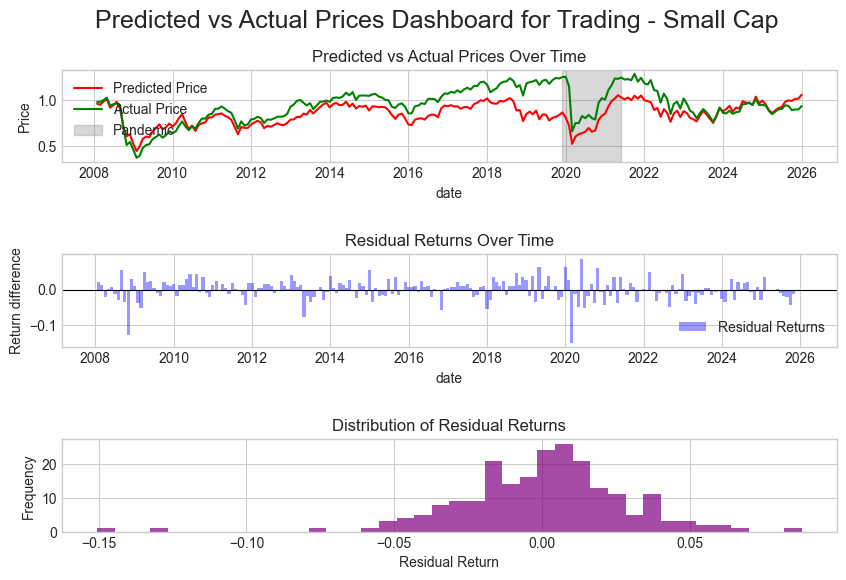

In [12]:
plotter.plot_dashboard_pred_vs_actual_prices(
    monthly_predicted_returns["Trading - Small Cap"],
    asset_name="Trading - Small Cap",
)

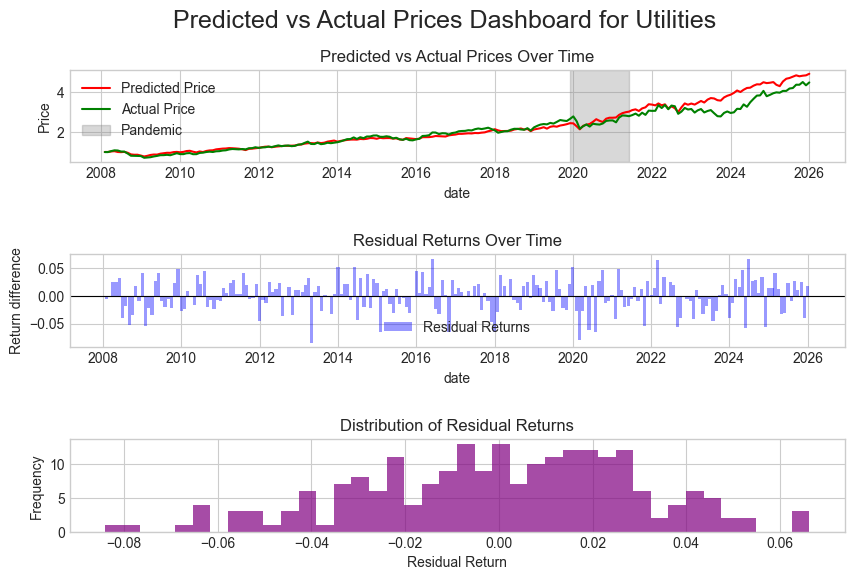

In [13]:
plotter.plot_dashboard_pred_vs_actual_prices(
    monthly_predicted_returns["Utilities"], "Utilities"
)

# Factor loadings entire period

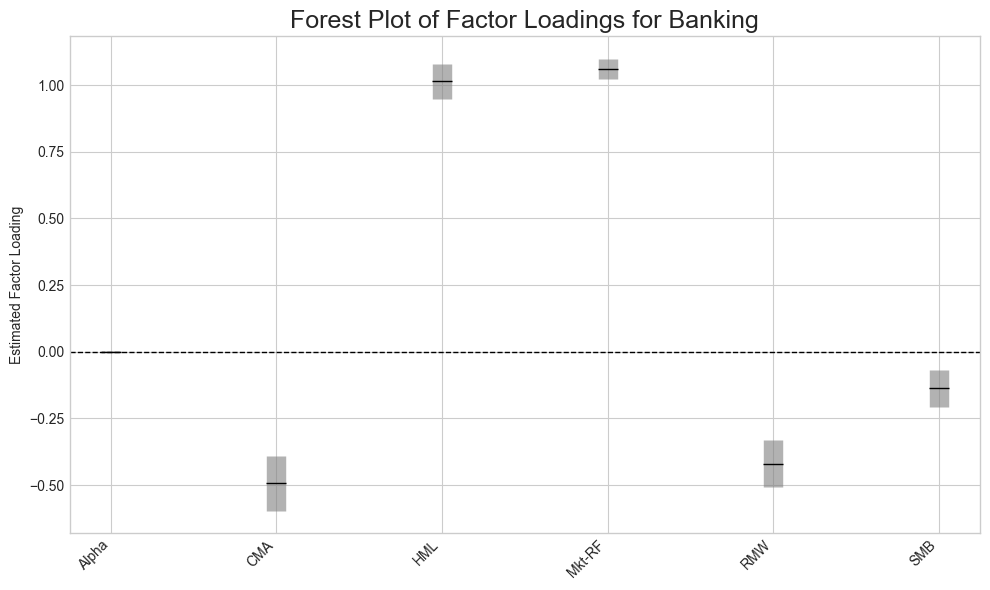

In [14]:
plotter.plot_factor_loadings(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Banking",
    asset_name="Banking",
)

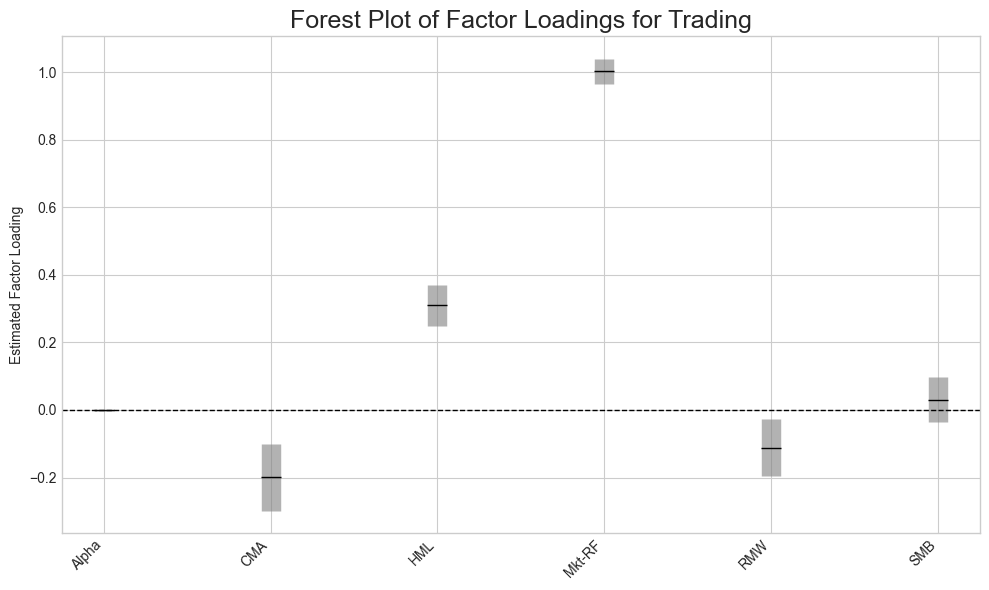

In [15]:
plotter.plot_factor_loadings(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Trading",
    asset_name="Trading",
)

## Factor Loadings Small vs Large cap

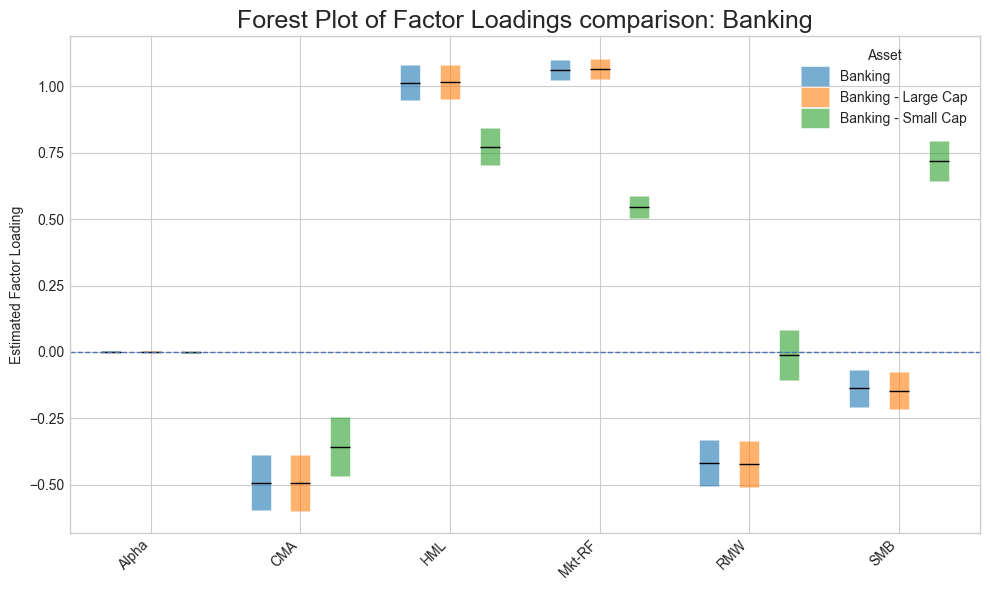

In [16]:
plotter.compare_factor_loadings_small_large(
    factor_loadings=monthly_factor_loadings,
    asset_identifier="Banking",
    asset_name="Banking",
)

# Factor loadings over time

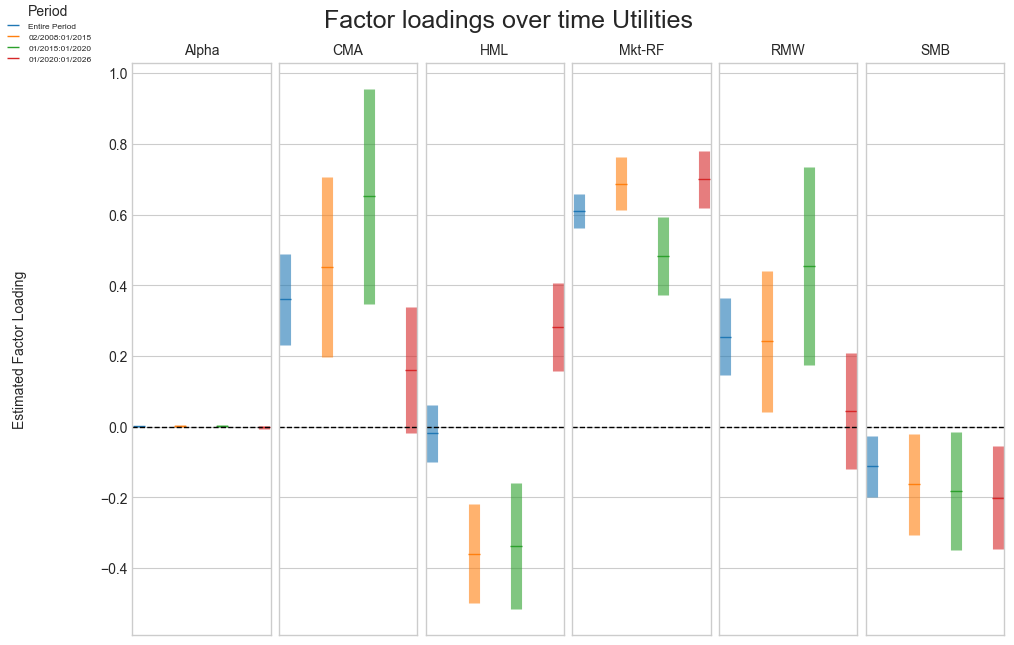

In [17]:
plotter.plot_factor_loadings_over_time(
    factor_loadings_over_time=factor_loadings_overtime,
    asset_identifier="Utilities",
    asset_name="Utilities",
)